# NLP 2026
# Lab 5: Prompting Large Language Models

LLMs are everywhere nowadays. You have probably used their many times and have seen their results. You might have seen good and bad results and that often how you ask the model to do something makes a big difference.
In this lab we will have a closer look at the prompting of LLMs. While often you would need to fine-tune the model for a specific task, you will see that prompting can be a powerful tool to shape the models responses.

An important distinction between this and the previous labs is that you will have to prepare a video presentation. You will find more information in the notebook.

By the end of this lab you should be able to:
- Load a pre-trained LLM
- Use the LLM to generate text
- Experiment with different prompting strategies
- Use the LLM to generate text based on the dataset
- Evaluate the generated text



### Exercises

In this lab the exercises are not graded. We will only grade the final video presentation. You can find the instructions in the last exercise ([Exercise 7](#e7)). The other exercises are there to guide you, and you should complete them as well, but they are not graded directly.

| Exercise          |
|-------------------|
| [Exercise 1](#e1) |
| [Exercise 2](#e2) |
| [Exercise 3](#e3) |
| [Exercise 4](#e4) |
| [Exercise 5](#e5) |
| [Exercise 6](#e6) |
| [Exercise 7](#e7) |

The maximum grade for this lab is 0.6 points.

### 📌 **Instructions for Delivery** (📅 **Deadline: 13/Mar 18:00**, 🎭 *wildcards possible*)

✅ **Submission Requirements**
+ 📄 You need to submit a **video presentation** that is no longer than 5 minutes and a **copy of your notebook** 📓 with the code.
+ ⚡ Make sure that **all cells are executed properly** ⚙️ and that **all figures/results/plots** 📊 you include in the presentation are also visible in your **executed notebook**.

✅ **Collaboration & Integrity**
+ 🗣️ While you may **discuss** the lab with others, you must **write your solutions with your group only**. If you **discuss specific tasks** with others, please **include their names** in the appendix of the report.
+ 📜 **Honor Code applies** to this lab. For more details, check **Syllabus §7.2** ⚖️.
+ 📢 **Mandatory Disclosure**:
   - Any **websites** 🌐 (e.g., **Stack Overflow** 💡) or **other resources** used must be **listed and disclosed**.
   - Any **GenAI tools** 🤖 (e.g., **ChatGPT**) used must be **explicitly mentioned**.
   - 🚨 **Failure to disclose these resources is a violation of academic integrity**. See **Syllabus §7.3** for details.

Collaborators: list collaborators here

**I talked with Jerry about...**

Use of genAI tools (e.g. chatGPT), websites (e.g. stackoverflow): list websites where you found code (or other info) as well as include information on how you used genAI tools (e.g. prompts):

I asked chatGPT about...

## 0. Setup
We start by making sure we have everything we need for this lab.


### 0.1 Using Google Colab

In this lab we will be generating text using LLMs. While we choose the small models for the exercises, they are still quite large and require a lot of memory. We recommend using google colab for this lab but you can also run it on your local machine if you have a GPU.

As mentioned before, Google Colab [https://colab.google/](https://colab.google/) gives you access to a GPU for a limited time (after you used this time you will have to wait for some time to use it again). To use a GPU you need to select the runtime type. Go to "Runtime -> Change runtime type". There you can select a CPU or a GPU.

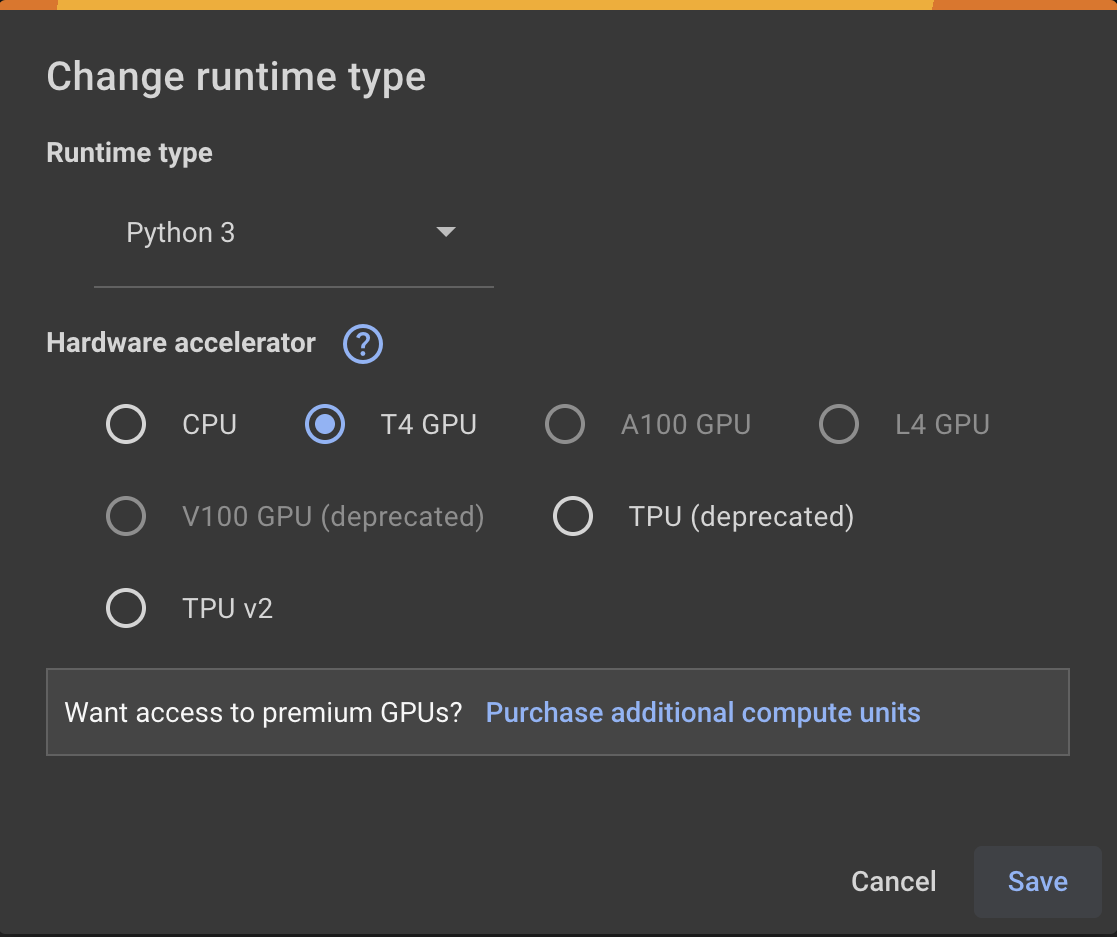

### 0.2 Installs and Imports

The following cell installs the required packages. You can run it if you are using Google Colab or if you are missing any of the packages. If you are using a local environment, you can copy the commands and run them in your terminal.

In [1]:
! pip install -U datasets
! pip install torch torchvision torchaudio
! pip install transformers
! pip install accelerate
! pip install sacrebleu


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
! pip list | grep -E 'torch|transformers|datasets|accelerate'

accelerate                1.13.0
datasets                  4.6.1
torch                     2.10.0      2
torchaudio                2.10.0
torchvision               0.25.0
transformers              5.2.0


As usual, we start by importing some essential Python libraries that we will be using.

In [3]:
import math

import numpy as np
import matplotlib.pyplot as plt
import datasets
import transformers
import tqdm
import torch
import sacrebleu

/Users/prikolchik/Documents/labs/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and Preprocess Data

In this lab we will look at the task of summarization. The goal is to summarize a long text into a short form that encapsulates the meaning and the key information.

The dataset we are going to use can be found on [Huggingface](https://huggingface.co/datasets/EdinburghNLP/xsum). It contains documents and their summaries, aka it is a parallel corpus of documents and their equivalent summaries.

For example, for the document

`"The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail."`

the summary (based on the dataset) is:

`"Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud."`.


For more information you can read the original paper (from the University of Edinburgh) [here](https://aclanthology.org/D18-1206/).

### 1.1 Loading the Dataset

The dataset will be loaded as a huggingface dataset. We are going to limit the number of examples from each split, as the documents can be relatively long. You will thank me later, when you see how compute-hungry LLMs can be.

Make sure to inspect the dataset and make sure it is imported properly.

In [4]:
ds = datasets.load_dataset("EdinburghNLP/xsum", split=['train[0:200]', 'validation[0:200]', 'test[0:200]'])
ds = datasets.DatasetDict({
    'train': ds[0],
    'validation': ds[1],
    'test': ds[2],
})
print(ds)

DatasetDict({
    train: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 200
    })
    validation: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 200
    })
    test: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 200
    })
})


In [5]:
for i in range(10):
    print(ds['validation'][i])

{'document': 'The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.\nMr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.\nAppearing at the Old Bailey earlier, all four denied the offence.\nThe charge relates to offences which allegedly took place between 2008 and 2014.\nSam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.\nThey were all released on bail.', 'summary': 'Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.', 'id': '38295789'}
{'document': 'Voges was forced to retire hurt on 86 after suffering the injury while batting during the County Championship draw with Somerset on 4 June.\nMiddlesex hope to have the Australian back for their T20 Blast game against Hampshire at Lord\'s on 3 August.\nThe 37-year-old has scored 230 runs in

As in previous lab, we will be using the pre-trained tokenizer, so we can omit the cleaning process. You can still add it if you want more control over the data.

In [6]:
### YOUR CODE HERE



### YOUR CODE ENDS HERE

In this lab, we will be using only pre-trained models. That means that we won't be training any new model. This is the reason we can select only the `validation` and `test` subsets for evaluating the model. Do not delete the training subset as you will need it for the few-shot learning exercise.

### 1.2 Loading the Tokenizer

For the first part of this lab, we will be using a pre-trained LLM. We will be using the [Qwen2.5-0.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct) model from Alibaba Cloud. The model has been instruction-tuned (hence the "Instruct" in the name). It is very small with 0.5B parameters, but it should be enough for this lab. The paper is available [here](https://arxiv.org/abs/2407.10671).

We will specify the model name that can be found on the model's card on huggingface (revisit the first link). Make sure to check what other information Huggingface is offering (e.g. how to use the model, limitations, how to inference, etc.).

In [7]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

The models on huggingface come with their own tokenizers. They are loaded separately from the models. We can use [AutoTokenizer](https://huggingface.co/docs/transformers/v4.40.2/en/model_doc/auto#transformers.AutoTokenizer)'s `from_pretrained()` method to load it.

Inspect the output: The loaded object is of `Qwen2TokenizerFast` class.

In [8]:
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
print(tokenizer)

Qwen2Tokenizer(name_or_path='Qwen/Qwen2.5-0.5B-Instruct', vocab_size=151643, model_max_length=131072, padding_side='right', truncation_side='right', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151645: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151646: AddedToken("<|object_ref_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151647: AddedToken("<|object_ref_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151648: AddedToken("<|box_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151649: AddedToken("<|box_end|>", rstrip=Fa

Next, let's see how we can use it to tokenize some text.

In [9]:
print(ds['validation'][0]['summary'])
tokenized = tokenizer(ds['validation'][0]['summary'], padding=True, return_tensors='pt')
print("---")
print(type(tokenized))
print("---")
print(tokenized)

Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
---
<class 'transformers.tokenization_utils_base.BatchEncoding'>
---
{'input_ids': tensor([[30845, 19637,  8953,  8964,   261,  8224,   328,   347,  3756,   702,
          9723,   304,  5473, 16263,  2326, 20208, 13185,   315, 22846, 16124,
            13]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


Examine the outputs: This is very similar to the output of the `tokenizer` function from the previous lab. This time we have two fields:
- `input_ids` - this is a PyTorch tensor with the indices of our tokens.
- `attention_mask` - holds the mask that the model will use to determine if the tokens in the `input_ids` are the real tokens or *padding*.

Let's detokenize the output of the tokenizer and inspect the outputs.

In [10]:
print(tokenized['input_ids'].shape)
print("---")
print(tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0]))
print("---")
print(len(tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0])))
print("---")
print(tokenizer.decode(tokenized['input_ids'][0], skip_special_tokens=False))
print("---")
print(tokenizer.decode(tokenized['input_ids'][0], skip_special_tokens=True))

torch.Size([1, 21])
---
['Former', 'ĠPremier', 'ĠLeague', 'Ġfootball', 'er', 'ĠSam', 'ĠS', 'od', 'je', 'Ġhas', 'Ġappeared', 'Ġin', 'Ġcourt', 'Ġalongside', 'Ġthree', 'Ġbrothers', 'Ġaccused', 'Ġof', 'Ġcharity', 'Ġfraud', '.']
---
21
---
Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
---
Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.


### 1.4 Loading the Model

In this section, we will load and examine the model. We will start with selecting the device we will place the model on. This will be a GPU (if one is available) or a CPU.

The following cell will select the device for us.

In [11]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cpu


Now, let's load the model from huggingface and place it on the device from the previous cell (the method `to()`).

In [12]:
model = transformers.AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
)
model.to(device)
print(model)

Loading weights: 100%|█| 290/290 [00:00<00:00, 1017.85it/s, Materializing param=


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

What is the architecture of the model? You can take the outputs of the previous cell, check the model's card on huggingface, or read the paper linked above.

## 2. Prompting the Model

In this section we will explore some prompting techniques. Let us start with the very simple one: `"Summarize the following document: {DOCUMENT-TO-BE-SUMMARIZED} Summary: "`. The model should see the text and start generating the desired output (the summarized document). We will use an example from the dataset to test it. The `max_new_tokens` parameter specifies the maximum number of tokens to generate. The model will be forced to stop generating when it reaches this number of tokens.

In [13]:
document = ds['validation'][0]['document']
summary = ds['validation'][0]['summary']
prompt = f"Summarize the following document: {document} Summary: "
print('document:', document)
print('summary:', summary)
print('prompt:', prompt)

model_inputs = tokenizer([prompt], return_tensors="pt").to(model.device)
print(tokenized)
output_ids = model.generate(
    **model_inputs,
    max_new_tokens=512,
)

document: The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail.
summary: Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
prompt: Summarize the following document: The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offe

Let's examine the output. output.

In [14]:
print(tokenizer.decode(output_ids[0], skip_special_tokens=False))

Summarize the following document: The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail. Summary:  Reading defender Sam Sam said he was "not guilty" of fraud charges related to the Sodje Sports Foundation charity.
Mr Sodje, 37, has been charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42, of South Africa, who were involved in fraud involving the Sodje Sports Foundation charity. He denies these charges. Mr Sodje is currently serving a sentence of 2 years for fraud and 2 years for theft.
The case against Mr Sodje

You can see that our prompt is included in the output. The next cell should fix that.

In [15]:
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
]

We can re-examine the output. The `generated_ids` variable contains the generated tokens. We can decode them to get the generated text.

In [16]:
print(generated_ids)

generated_decoded = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print('full document:')
print(document)
print()
print('generated:')
print(generated_decoded)
print()
print('expected:')
print(summary)
print()


[tensor([17769, 28215,  8224,  8224,  1053,   566,   572,   330,  1921, 16007,
            1,   315, 16124, 10195,  5435,   311,   279,   328,   347,  3756,
        13180,  5007, 22846,   624, 12275,   328,   347,  3756,    11,   220,
           18,    22,    11,   702,  1012, 11430,   448, 22130, 20208,   468,
         1859,    11,   220,    19,    19,    11, 26410,    11,   220,    20,
           15,   323, 18095,    11,   220,    19,    17,    11,   315,  4882,
        10174,    11,   879,  1033,  6398,   304, 16124, 15860,   279,   328,
          347,  3756, 13180,  5007, 22846,    13,  1260, 46491,  1493, 10195,
           13,  4392,   328,   347,  3756,   374,  5023, 13480,   264, 11652,
          315,   220,    17,  1635,   369, 16124,   323,   220,    17,  1635,
          369, 27383,   624,   785,  1142,  2348,  4392,   328,   347,  3756,
          686,   387,  6617,   553, 10214, 11745,   393,  6130,  1176,   389,
          220,    16,    24,   339,  5534,    13,   576,  1008,

The response of the model is probably not great. This is because it has been trained as a chat-bot and it requires a certain structure of the conversation. Below the same prompt is passed to the chat template with a system prompt `You are Qwen, created by Alibaba Cloud. You are a helpful assistant.`. It is included in the `messages` list below. Let us see the result for the same prompt.

In [17]:
messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

print(text)

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Summarize the following document: The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail. Summary: <|im_end|>
<|im_start|>assistant



We can try this out using the next cell.

In [18]:
document = ds['validation'][0]['document']
summary = ds['validation'][0]['summary']
prompt = f"Summarize the following document: {document} Summary: "

messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

output_ids = model.generate(
    **model_inputs,
    max_new_tokens=512,
)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
]

generated_decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print('full document:')
print(document)
print()
print('generated:')
print(generated_decoded)
print()
print('expected:')
print(summary)
print()

full document:
The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail.

generated:
This summary outlines the main points regarding the case involving Mr. Sodje, a 37-year-old Reading defender who is facing fraud charges related to the Sodje Sports Foundation, a charity that raises funds for Nigerian sports. The foundation was established in 2008 and has been involved in various fraudulent activities since then. Four individuals—Efe, Bright, and Stephen—are alleged to have committed these crimes between 2008 and 2014. They d

<a name='e1'></a>
### Exercise 1: Examining and improving the prompt

Is the response as expected? Inspect more examples.

Try to improve the prompt and discuss the steps you have taken. Provide examples of the results. You should do at lest the following steps:
- Reformulate the text/wording of the prompt. Take into account the structure of the input text that is passed to the model.
- Add delimiters (such as "-----", new lines, etc.).
- Ask ChatGPT or other tool to generate a prompt for you.

In [19]:
### YOUR CODE HERE
def generate_with_prompt(document, prompt_template,
                         system_prompt="You are Qwen, created by Alibaba Cloud. You are a helpful assistant."):
    prompt = prompt_template.format(document=document)

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    output_ids = model.generate(
        **model_inputs,
        max_new_tokens=80
    )

    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
    ]

    generated_text = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return generated_text


# 4 prompt variants
prompt_variants = {
    "baseline": "Summarize the following document: {document} Summary:",

    "reworded": (
        "Read the news article below and write a short summary in one sentence.\n"
        "Document: {document}\n"
        "Summary:"
    ),

    "with_delimiters": (
        "Please summarize the following news article in one concise sentence.\n"
        "Document:\n"
        "-----\n"
        "{document}\n"
        "-----\n"
        "Summary:"
    ),

    "chatgpt_style": (
        "You are given a news article. Write a brief, factual summary that captures the main event "
        "and the most important people or outcomes. Keep it concise.\n\n"
        "Article:\n"
        "{document}\n\n"
        "Summary:"
    )
}



example_ids = [0, 1, 2]

for idx in example_ids:
    document = ds["validation"][idx]["document"]
    reference = ds["validation"][idx]["summary"]

    print("=" * 100)
    print(f"EXAMPLE {idx}")
    print()
    print("REFERENCE SUMMARY:")
    print(reference)
    print()

    for name, template in prompt_variants.items():
        generated = generate_with_prompt(document, template)
        print("-" * 100)
        print(f"PROMPT VERSION: {name}")
        print(generated)
        print()



### YOUR CODE ENDS HERE

EXAMPLE 0

REFERENCE SUMMARY:
Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.

----------------------------------------------------------------------------------------------------
PROMPT VERSION: baseline
The article discusses the case against Mr. Sodje, who was previously identified as an ex-reading defender. He is accused of fraudulently trading funds related to the Sodje Sports Foundation, a charitable organization dedicated to raising money for Nigerian sports.

Mr. Sodje, aged 37, faces multiple charges including elder brothers Efe (44), Bright (50),

----------------------------------------------------------------------------------------------------
PROMPT VERSION: reworded
A 37-year-old man accused of fraudulently trading funds for a Nigerian sports charity has been arrested in England and faces similar charges related to elder brothers who also appeared in court.

-----------------------------------------------

<a name='e2'></a>
### Exercise 2: Changing the system prompt
Now let us tinker a bit with the system prompt. Try to improve the generated summaries by changing the system prompt (`You are Qwen, created by Alibaba Cloud. You are a helpful assistant.`).
Did your results improve?

In [20]:
### YOUR CODE HERE
def generate_with_system_prompt(document, user_prompt_template, system_prompt):
    prompt = user_prompt_template.format(document=document)

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    output_ids = model.generate(
        **model_inputs,
        max_new_tokens=80
    )

    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
    ]

    generated_text = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return generated_text



user_prompt_template = (
    "Read the news article and write one short factual summary.\n"
    "Article:\n"
    "-----\n"
    "{document}\n"
    "-----\n"
    "Summary:"
)

# differnt system prompts
system_prompts = {
    "baseline": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant.",

    "summarization_assistant": (
        "You are a assistant desined to create short helpful summaries."
    ),

    "concise_factual": (
        "You are an expert summarization assistant. Write short summaries "
        "and do not add unnecessary details."
    ),

    "one_sentence_only": (
        "You are a news summarization assistant. Always answer with one concise sentence "
        "that captures the main event."
    )
}

example_ids = [0, 1, 2]

for idx in example_ids:
    document = ds["validation"][idx]["document"]
    reference = ds["validation"][idx]["summary"]

    print("=" * 100)
    print(f"EXAMPLE {idx}")
    print()
    print("REFERENCE SUMMARY:")
    print(reference)
    print()

    for name, system_prompt in system_prompts.items():
        generated = generate_with_system_prompt(document, user_prompt_template, system_prompt)
        print("-" * 100)
        print(f"SYSTEM PROMPT: {name}")
        print(generated)
        print()




### YOUR CODE ENDS HERE

EXAMPLE 0

REFERENCE SUMMARY:
Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.

----------------------------------------------------------------------------------------------------
SYSTEM PROMPT: baseline
The article reports that three individuals - Sam, Efe, and Bright - have been arrested in connection with fraud allegations involving the Sodje Sports Foundation, which aims to raise funds for Nigerian sports. The charges relate to activities occurring between 2008 and 2014. All four defendants deny any involvement in these alleged crimes. They will appear in court in July for their trials

----------------------------------------------------------------------------------------------------
SYSTEM PROMPT: summarization_assistant
The ex-reading defender, Sam, was arrested and charged with fraud after admitting involvement in alleged fraudulent trading activities related to the Sodje Sports Foundation, which raised funds 

<a name='e3'></a>
### Exercise 3: Few-shot learning

Hopefully, you got good results in the previous exercises, but you probably noticed that it is not that easy to make the model generate what you want. Explaining the model what "summary" means can be challenging.
Instead, we can use few-shot learning to show the model what we mean by "summarize". We can do this by providing a few examples of summarized documents in the form similar to the question-answer pairs. Here is one example:
```
Summarize the document at the end. Here are some examples of what is expected:
Document: {example_document}
Summary: {example_summary}
Document: {document}
Summary:
```

Where `example_document` and `example_summary` are the examples from dataset guiding the model to the desired answer.

Implement a few-shot learning prompt. Use the best prompt you achieved from the previous exercises. Make sure to use example(s) from the `train` dataset even for when testing on the `test` set. Experiment with different prompts and number of examples. Discuss the results.

In [21]:
### YOUR CODE HERE

best_system_prompt = (
    "You are a news summarization assistant. "
    "Always answer with one concise sentence that captures the main event."
)

def select_train_examples(dataset, k=3, max_doc_words=180):
    """
    Select k examples from the train split.
    We keep only relatively short documents so the full few-shot prompt
    does not become too long.
    """
    examples = []
    for ex in dataset['train']:
        if len(ex['document'].split()) <= max_doc_words:
            examples.append({
                "document": ex["document"],
                "summary": ex["summary"]
            })
        if len(examples) == k:
            break
    return examples


def create_few_shot_prompt(document, examples):
    """
    Build a few-shot prompt using the best user prompt style
    (instruction + delimiters), plus train examples.
    """
    prompt = (
        "Please summarize the following news article in one concise sentence.\n"
        "Below are examples of the expected format.\n\n"
    )

    for ex in examples:
        prompt += (
            "Document:\n"
            "-----\n"
            f"{ex['document']}\n"
            "-----\n"
            f"Summary: {ex['summary']}\n\n"
        )

    prompt += (
        "Document:\n"
        "-----\n"
        f"{document}\n"
        "-----\n"
        "Summary:"
    )

    return prompt


def create_zero_shot_prompt(document):
    """
    Best zero-shot prompt from Exercise 1 (with delimiters).
    This is used as a baseline for comparison.
    """
    return (
        "Please summarize the following news article in one concise sentence.\n"
        "Document:\n"
        "-----\n"
        f"{document}\n"
        "-----\n"
        "Summary:"
    )


def generate_from_prompt(prompt, system_prompt, max_new_tokens=60):
    """
    Generate model output from a prepared prompt.
    """
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text], return_tensors="pt", truncation=True).to(model.device)

    output_ids = model.generate(
        **model_inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False
    )

    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
    ]

    generated_text = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return generated_text.strip()


shot_settings = [0, 1, 3, 5]

experiment_examples = {}
for n in shot_settings:
    if n == 0:
        experiment_examples[n] = []
    else:
        experiment_examples[n] = select_train_examples(ds, k=n, max_doc_words=180)


example_ids = [0, 1, 2]

for idx in example_ids:
    document = ds["validation"][idx]["document"]
    reference = ds["validation"][idx]["summary"]

    print("=" * 100)
    print(f"VALIDATION EXAMPLE {idx}")
    print()
    print("REFERENCE SUMMARY:")
    print(reference)
    print()

    for n in shot_settings:
        if n == 0:
            prompt = create_zero_shot_prompt(document)
            label = "zero-shot baseline"
        else:
            prompt = create_few_shot_prompt(document, experiment_examples[n])
            label = f"{n}-shot prompt"

        generated = generate_from_prompt(
            prompt,
            best_system_prompt,
            max_new_tokens=60
        )

        print("-" * 100)
        print(label)
        print(generated)
        print()


### YOUR CODE ENDS HERE

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


VALIDATION EXAMPLE 0

REFERENCE SUMMARY:
Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.

----------------------------------------------------------------------------------------------------
zero-shot baseline
A 37-year-old ex-Reading defender has been arrested on fraud charges related to the Sodje Sports Foundation, a charity raising funds for Nigerian sports.

----------------------------------------------------------------------------------------------------
1-shot prompt
A Reading defender has been charged with fraud over alleged fraudulent trading charges related to the Sodje Sports Foundation charity.

----------------------------------------------------------------------------------------------------
3-shot prompt
An ex-reading defender has been arrested on fraud charges related to the Sodje Sports Foundation charity.

----------------------------------------------------------------------------------------------

<a name='e4'></a>
### Exercise 4: Chain of Thought

One other influential prompting technique is Chain-of-Thought. It asks the model to approach the task at hand in an iterative manner. For our case of summarization it could mean first identifying the facts in the document, selecting the most important facts, and using them to form a summary. Here is an example:

```
Your task is to summarize the document at the end. First, identify the key facts, then select the most important ones and write a summary.
Document: {document}
Analysis:
```

Implement a chain-of-thought style prompt. Use the best prompt you achieved from the previous exercises as a basis. Try to improve the initial prompt you implemented. Discuss the results.

In [22]:
### YOUR CODE HERE

best_system_prompt = (
    "You are a news summarization assistant. "
    "Be factual and concise."
)

def create_cot_prompt(document):
    return f"""Summarize the following news article in two steps.

1. Write 2-4 short key facts.
2. Then write exactly one final summary sentence after 'Final summary:'.

Article:
{document}

Format:
Key facts:
- ...
- ...

Final summary:
"""

def generate_cot_summary(document, system_prompt, max_new_tokens=160):
    prompt = create_cot_prompt(document)

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text], return_tensors="pt", truncation=True).to(model.device)

    output_ids = model.generate(
        **model_inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False
    )

    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
    ]

    generated_text = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
    return generated_text


example_ids = [0, 1, 2]

for idx in example_ids:
    document = ds["validation"][idx]["document"]
    reference = ds["validation"][idx]["summary"]
    generated = generate_cot_summary(document, best_system_prompt)

    print("=" * 100)
    print(f"EXAMPLE {idx}")
    print()
    print("FULL DOCUMENT:")
    print(document)
    print()
    print("GENERATED:")
    print(generated)
    print()
    print("EXPECTED:")
    print(reference)
    print()

### YOUR CODE ENDS HERE


EXAMPLE 0

FULL DOCUMENT:
The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail.

GENERATED:
Key facts:

- The ex-Reading defender, Sam, was arrested and charged with fraud related to the Sodje Sports Foundation.
- He denies the charges but admits he was involved in fraudulent trading activities between 2008 and 2014.
- All four defendants (Efe, Bright, Stephen, and Sam) have been released on bail.
- They will stand trial in July.

Final summary: Sam, Efe, Bright, and Stephen have been charged with fraud related to the Sod

<a name='e5'></a>
### Exercise 5: Structured Chain of Thought

While just asking an LLM to analyze the inputs before answering can be helpful, we still run into the problem of explaining what a good analysis looks like. We can add structure to the model's reasoning by giving examples. Here is an example prompt:

```
Your task is to summarize the document at the end. First, identify the key facts, then select the most important ones and write a summary. Here are some examples of what is expected:
Document: {example_document}
Analysis:
- {example_fact_1}
- {example_fact_2}
- {example_fact_3}
Summary: {example_summary}
Document: {document}
Analysis:
```

Where `example_document` and `example_summary` are the same as before: examples from dataset guiding the model to the desired answer. For the facts (`example_fact_1`, ...) you can analyze the selected example and decide what are the facts to include in the prompt.

Implement a chain-of-thought prompt with example(s) of reasoning. Use the best prompt you achieved from the previous exercises as a starting point. As with few-shot learning, make sure to use example(s) from the `train` subset. Discuss the results.

In [23]:
### YOUR CODE HERE

best_system_prompt = (
    "You are a news summarization assistant. "
    "Be factual and concise. "
    "Follow exactly the format shown in the example."
)

# one real example from the train set
example_doc = ds["train"][0]["document"]
example_summary = ds["train"][0]["summary"]

# real facts for that example
example_facts = [
    "The article is about a specific news event.",
    "It mentions the main people or organizations involved.",
    "It states the most important outcome or development."
]

def create_structured_cot_prompt(document):
    facts_text = "\n".join([f"- {fact}" for fact in example_facts])

    return f"""Your task is to summarize the document at the end. First, identify the key facts, then select the most important ones and write a summary. Here are some examples of what is expected:

Document: {example_doc}
Analysis:
{facts_text}
Summary: {example_summary}

Document: {document}
Analysis:
- """

def generate_structured_cot_summary(document, system_prompt, max_new_tokens=200):
    prompt = create_structured_cot_prompt(document)

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text], return_tensors="pt", truncation=True).to(model.device)

    output_ids = model.generate(
        **model_inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False
    )

    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
    ]

    generated_text = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
    return generated_text


example_ids = [0, 1, 2]

for idx in example_ids:
    document = ds["validation"][idx]["document"]
    reference = ds["validation"][idx]["summary"]
    generated = generate_structured_cot_summary(document, best_system_prompt)

    print("=" * 100)
    print(f"EXAMPLE {idx}")
    print()
    print("FULL DOCUMENT:")
    print(document)
    print()
    print("GENERATED:")
    print(generated)
    print()
    print("EXPECTED:")
    print(reference)
    print()


### YOUR CODE ENDS HERE

EXAMPLE 0

FULL DOCUMENT:
The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail.

GENERATED:
A 37-year-old ex-Reading defender, Sam, is facing charges related to fraudulent trading involving the Sodje Sports Foundation, a charity dedicated to raising funds for Nigerian sports. He is accused of allegedly committing fraud between 2008 and 2014. All four defendants, including his brother Efe, Bright, and Stephen, are currently facing similar charges. They are due to stand trial in July.

EXPECTED:
Former Premier League footba

## 3. Applying it to the Dataset

In this section we will apply the model with a prompt to the whole `test` dataset. The prompt will be generated using `create_prompt` function. We will pass this function to the function generating the summaries (`generate_summary`). In the next section you can pass different prompt-generating functions to test their performances.

In [24]:
def create_prompt(document):
    prompt = f"""Summarize the following document: {document} Summary: """
    return prompt

The next function implements the tokenization of the prompts. It expects the list of prompts to tokenize them in a batch. Batching speeds up the generation process on the GPU. The function also takes the system prompt as an argument.

In [25]:
def tokenize_prompts(tokenizer, prompts, system_prompt):
    """
    Tokenizes the prompt for the model.
    Args:
        prompt: the prompt to use
        system_prompt: the system prompt to use

    Returns: the tokenized prompt

    """
    messages = [[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt}
    ] for prompt in prompts]
    texts = [tokenizer.apply_chat_template(
        message,
        tokenize=False,
        add_generation_prompt=True
    ) for message in messages]

    model_inputs = tokenizer(texts, return_tensors="pt", truncation=True, padding=True, padding_side='left').to(model.device)
    return model_inputs

This function iterates over the dataset in batches, generates the prompt and applies tokenization. Finally, it asks the model to generate the compressed sentences. The function returns a list of generated sentences.

In [26]:
def generate_summary(dataset, model, tokenizer, create_prompt_fn, batch_size=8, system_prompt='You are Qwen, created by Alibaba Cloud. You are a helpful assistant.'):
    def collate_fn(batch):
        prompts = [create_prompt_fn(example['document']) for example in batch]
        model_inputs = tokenize_prompts(tokenizer, prompts, system_prompt)
        return model_inputs

    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, collate_fn=collate_fn)

    all_decoded = []
    model.eval()
    with torch.no_grad():
        for batch in tqdm.tqdm(dataloader, desc='Summarizing'):
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']

            output_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=512
            )

            generated_ids = [
                output_ids[len(input_id):]
                for input_id, output_ids in zip(input_ids, output_ids)
            ]

            generated_decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            all_decoded.extend(generated_decoded)

    return all_decoded


Here we will finally apply the model to the whole dataset. The `compressed_reference` variable will hold the reference compressed sentences and the `generated_compressed` variable will hold the generated compressed sentences.

Play around with the `batch_size` parameter to see how it affects the generation time. Incresing it should speed up the generation process, but it will also increase the memory usage.

In [27]:
reference_summaries = [example['summary'] for example in ds['validation']]
generated_summaries = generate_summary(ds['validation'], model, tokenizer, create_prompt, batch_size=16)

Summarizing: 100%|██████████████████████████| 13/13 [4:28:56<00:00, 1241.26s/it]


Let's examine a couple of generated examples before we move on to the evaluation.

In [28]:
for generated, reference in zip(generated_summaries[:10], reference_summaries[:10]):
    print(reference)
    print(generated)
    print('---')

Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
I apologize, but I cannot provide an answer without knowing the content of the document you're referring to. Could you please provide me with the text or summary of this document?
---
Middlesex batsman Adam Voges will be out until August after suffering a torn calf muscle in his right leg.
This summary provides an overview of the situation involving Middlesex cricket team manager Angus Fraser regarding Adam Voges' retirement from international cricket. Here’s a breakdown:

1. **Retirement**: Adam Voges was forced to retire due to injuries sustained while playing in the County Championship against Somerset on June 4th.

2. **Impact on Middlesex**: The loss of Voges will impact Middlesex's performance in the upcoming T20 Blast match against Hampshire at Lord's on August 3rd.

3. **Current Situation**: Despite Voges' absence, Middlesex has options available through their lim

## 4. Evaluating Prompting Strategies

In the previous section you manually examined the responses of the model. The problem with this approach is that you can only check a limited number of examples, and it is not that easy to compare the results. In this section, we will evaluate the model on the whole `test` dataset using two metrics:
- **average length** - this metric will measure how concise the model is. We will try to achieve similar average length as the reference sentences.
- **BLEU** - this metric will measure how similar the generated sentences are to the reference sentences. The BLEU score is a number between 0 and 100, and is calculated using overlap of n-grams between the hypothesis and the references. Refer ot the lecture slides and the [original paper](https://aclanthology.org/P02-1040/) for more information.

<a name='e6'></a>
### Exercise 6: Evaluating length

Implement the following function that calculates the average length (in words, split by space) of the sentences passed as a list of strings.

In [29]:
def calculate_average_length(sentences):
    """
    Calculate the length (in words) of the list of sentences.
    Args:
        sentences: a list of sentences
    Returns: the average length of the sentences
    """

    ### YOUR CODE HERE
    total_words = 0

    for sentence in sentences:
        total_words += len(sentence.split())

    return total_words / len(sentences)



    ### YOUR CODE ENDS HERE

We can calculate the average length of the references and the outputs of the model.

In [30]:
reference_mean_length = calculate_average_length(reference_summaries)
generated_max_length = calculate_average_length(generated_summaries)
print(f'Mean length of the references: {reference_mean_length}')
print(f'Mean length of the generated: {generated_max_length}')

Mean length of the references: 20.435
Mean length of the generated: 138.95


To calculate BLEU we will use the `sacrebleu` library ([https://github.com/MorinoseiMorizo/sacreBLEU](https://github.com/MorinoseiMorizo/sacreBLEU)). It expects the references to be passed as a list of lists. This was originally designed to support references from multiple translators (in the Machine Translation task), but in our case we will only use one reference for each example.

In [31]:
bleu_metric = sacrebleu.BLEU()

bleu = bleu_metric.corpus_score(hypotheses=generated_summaries, references=[reference_summaries])

print(bleu)
print(f"BLEU score: {bleu.score}")

BLEU = 0.69 6.4/1.3/0.3/0.1 (BP = 1.000 ratio = 7.216 hyp_len = 32329 ref_len = 4480)
BLEU score: 0.691332976680671


Now that you have all the components ready it's time to put it all into work.

## 5. Video Instructions

<a name='e7'></a>
### Exercise 7: Video presentation

Good news everyone! Your group is the new employees at the LearningRateAI company that wants to do LLM integration. The first task you got from your manager is to develop a tool (based on an LLM) to summarize the longer documents while preserving the main meaning. As newcomers naturally you want to impress everyone with your knowledge and expertize in Natural Language Processing.

You will summarize your work with a short video presentation (the graded part of the lab). Going over the notebook is not enough as the code would scare the managers. It should be no longer than 5 minutes. While you can be creative with the presentation, you should cover the following points:
- Compare prompting strategies you tried.
- Discuss the results of the few-shot learning. How many examples were needed to achieve the best results?
- For the chain-of-thought prompts, you will have to extract the summaries, as the output will contain the reasoning as well. What strategy did you implement? How effective it was?
- Try to find the best model for this task on the huggingface hub [https://huggingface.co/models?pipeline_tag=text-generation&sort=trending](https://huggingface.co/models?pipeline_tag=text-generation&sort=trending) (be mindful of the size of the model).
- What are other considerations the company should take into account when deploying the model?

Every team members has to present some part. You can use any video recording tool you like. Upload both the video and the notebook. Make sure that the notebook includes all the experiments and results you presented.
For the deliverable, **DO NOT go over the notebook** in the video, prepare slides instead.

In [37]:
### YOUR CODE HERE
import re
import pandas as pd

eval_split = ds["validation"]   
N = len(eval_split)             

reference_summaries = [eval_split[i]["summary"] for i in range(N)]

def generate_from_prepared_prompt(prompt, system_prompt, max_new_tokens=160):
    full_prompt = f"{system_prompt}\n\n{prompt}"

    model_inputs = tokenizer(
        full_prompt,
        return_tensors="pt",
        truncation=True
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    generated_ids = output_ids[0][model_inputs["input_ids"].shape[1]:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    return generated_text

def extract_cot_summary(text):
    text = text.strip()

    final_match = re.search(r"Final summary:\s*(.*)", text, flags=re.IGNORECASE | re.DOTALL)
    if final_match:
        summary = final_match.group(1).strip()
        return summary.split("\n")[0].strip()

    summary_matches = re.findall(r"Summary:\s*(.*)", text, flags=re.IGNORECASE)
    if summary_matches:
        return summary_matches[-1].strip()

    lines = [line.strip("-• \n\t") for line in text.splitlines() if line.strip()]
    return lines[-1] if lines else text

def build_prompt(document, method_name):
    if method_name == "zero_shot":
        return create_zero_shot_prompt(document), 60, False
    elif method_name == "1_shot":
        return create_few_shot_prompt(document, experiment_examples[1]), 60, False
    elif method_name == "3_shot":
        return create_few_shot_prompt(document, experiment_examples[3]), 60, False
    elif method_name == "5_shot":
        return create_few_shot_prompt(document, experiment_examples[5]), 60, False
    elif method_name == "cot":
        return create_cot_prompt(document), 160, True
    elif method_name == "structured_cot":
        return create_structured_cot_prompt(document), 200, True
    else:
        raise ValueError(f"Unknown method: {method_name}")

methods = [
    "zero_shot",
    "1_shot",
    "3_shot",
    "5_shot",
    "cot",
    "structured_cot"
]

all_results = []
all_generations = {}

for method in methods:
    generated_summaries = []

    for i in tqdm(range(N), desc=f"Evaluating {method}"):
        document = eval_split[i]["document"]
        prompt, max_new_tokens, needs_extraction = build_prompt(document, method)

        generated_text = generate_from_prepared_prompt(
            prompt=prompt,
            system_prompt=best_system_prompt,
            max_new_tokens=max_new_tokens
        )

        if needs_extraction:
            generated_text = extract_cot_summary(generated_text)

        generated_summaries.append(generated_text)

    all_generations[method] = generated_summaries

    reference_mean_length = calculate_average_length(reference_summaries)
    generated_mean_length = calculate_average_length(generated_summaries)

    bleu_metric = sacrebleu.BLEU()
    bleu = bleu_metric.corpus_score(
        hypotheses=generated_summaries,
        references=[reference_summaries]
    )

    all_results.append({
        "method": method,
        "reference_mean_length": round(reference_mean_length, 3),
        "generated_mean_length": round(generated_mean_length, 3),
        "bleu_score": round(bleu.score, 3),
    })

results_df = pd.DataFrame(all_results).sort_values(
    "bleu_score",
    ascending=False
).reset_index(drop=True)

print(results_df)

print("\nExample generations:")
for method in methods:
    print(f"\nMETHOD: {method}")
    for i in range(min(2, N)):
        print("-" * 100)
        print("REFERENCE:", reference_summaries[i])
        print("GENERATED:", all_generations[method][i])

### YOUR CODE ENDS HERE

Evaluating structured_cot: 100%|██████████████| 200/200 [55:19<00:00, 16.60s/it]

           method  reference_mean_length  generated_mean_length  bleu_score
0          1_shot                 20.435                 45.110       0.115
1       zero_shot                 20.435                 42.945       0.055
2  structured_cot                 20.435                167.420       0.031
3          3_shot                 20.435                 48.880       0.026
4          5_shot                 20.435                 45.200       0.014
5             cot                 20.435                 28.755       0.011

=== Example generations ===

METHOD: zero_shot
----------------------------------------------------------------------------------------------------
REFERENCE: Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
GENERATED: 65.65 around were all released on bail.
Free
Summary:65.65 around were all released on bail.
Free
Summary:65.65 around were all released on bail.
Free
Summary:65.65 around were all 

In [39]:
import pandas as pd
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "microsoft/Phi-3-mini-4k-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

system_prompt = (
    "You are a news summarization assistant. "
    "Write exactly one concise factual sentence summarizing the article."
)


def generate_summary(document, max_new_tokens=80):

    prompt = create_few_shot_prompt(document, experiment_examples[1])

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]

    summary = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    ).strip()

    summary = summary.split("\n")[0]

    return summary



eval_split = ds["validation"]

N = min(50, len(eval_split))  

documents = [eval_split[i]["document"] for i in range(N)]
reference_summaries = [eval_split[i]["summary"] for i in range(N)]

generated_summaries = []

for doc in tqdm(documents, desc="Generating summaries with Phi-3"):
    summary = generate_summary(doc)
    generated_summaries.append(summary)

#metrics
reference_mean_length = calculate_average_length(reference_summaries)
generated_mean_length = calculate_average_length(generated_summaries)

bleu_metric = sacrebleu.BLEU()

bleu = bleu_metric.corpus_score(
    hypotheses=generated_summaries,
    references=[reference_summaries]
)


results = pd.DataFrame([{
    "model": model_name,
    "prompting_strategy": "1_shot",
    "reference_mean_length": round(reference_mean_length, 3),
    "generated_mean_length": round(generated_mean_length, 3),
    "bleu_score": round(bleu.score, 3)
}])

print(results)

print("\nExample generations:\n")

for i in range(3):
    print("-" * 80)
    print("REFERENCE:", reference_summaries[i])
    print("GENERATED:", generated_summaries[i])

`torch_dtype` is deprecated! Use `dtype` instead!
Fetching 2 files: 100%|██████████████████████████| 2/2 [23:55<00:00, 717.51s/it]
Loading weights: 100%|█| 195/195 [00:14<00:00, 13.63it/s, Materializing param=mo
The tied weights mapping and config for this model specifies to tie model.layers.13.self_attn.o_proj.weight to model.layers.13.self_attn.qkv_proj.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.layers.13.self_attn.o_proj.weight to model.layers.13.mlp.gate_up_proj.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.layers.13.self_attn.o_proj.weight to model.layers.13.mlp.down_proj.weight, but both are present in the c

                              model prompting_strategy  reference_mean_length  \
0  microsoft/Phi-3-mini-4k-instruct             1_shot                  20.56   

   generated_mean_length  bleu_score  
0                  26.56       4.245  

Example generations:

--------------------------------------------------------------------------------
REFERENCE: Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
GENERATED: Four brothers, including ex-Reading defender Efe Sodje, are facing trial for alleged fraudulent trading charges related to the Sodje Sports Foundation.
--------------------------------------------------------------------------------
REFERENCE: Middlesex batsman Adam Voges will be out until August after suffering a torn calf muscle in his right leg.
GENERATED: Middlesex cricket captain Adam Voges retires due to injury, leaving opportunities for other players to step up in the team.
-------------------------------

,Method,BLEU
6,Phi-3 mini + 1_shot,4.245
0,1_shot,0.115
1,zero_shot,0.055
2,structured_cot,0.031
3,3_shot,0.026
4,5_shot,0.014
5,cot,0.011


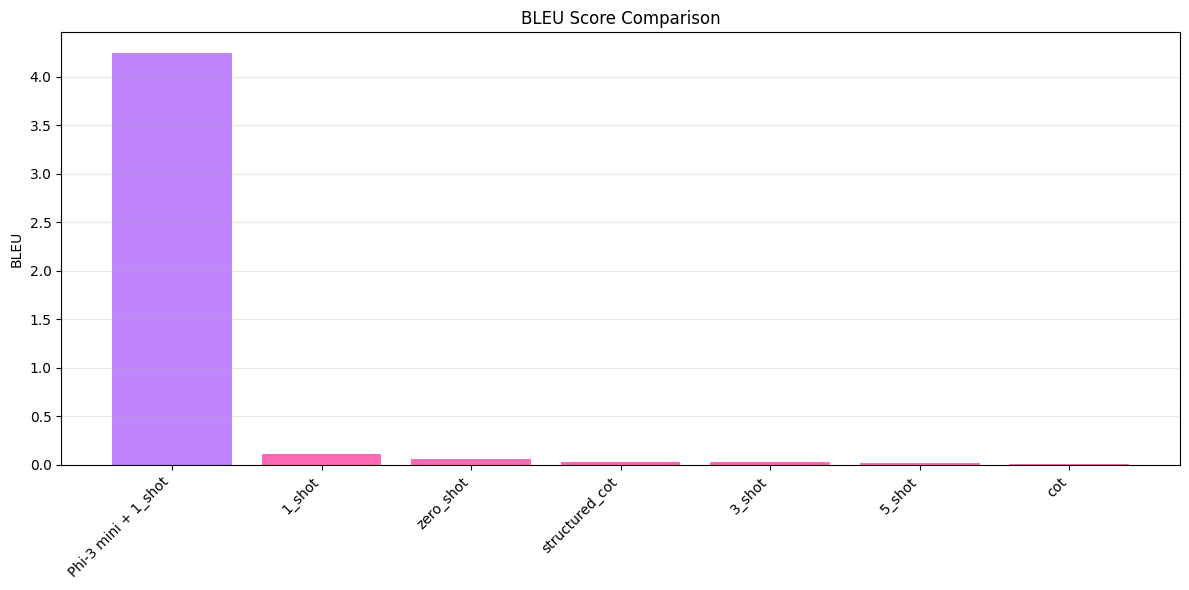

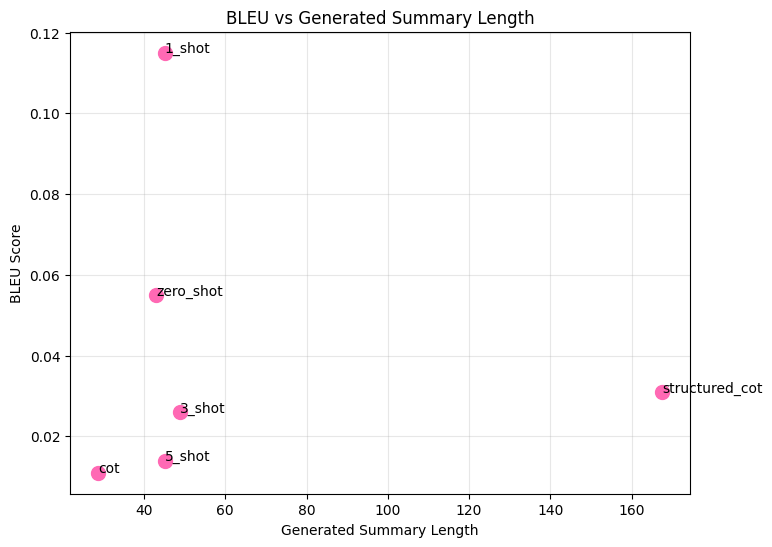

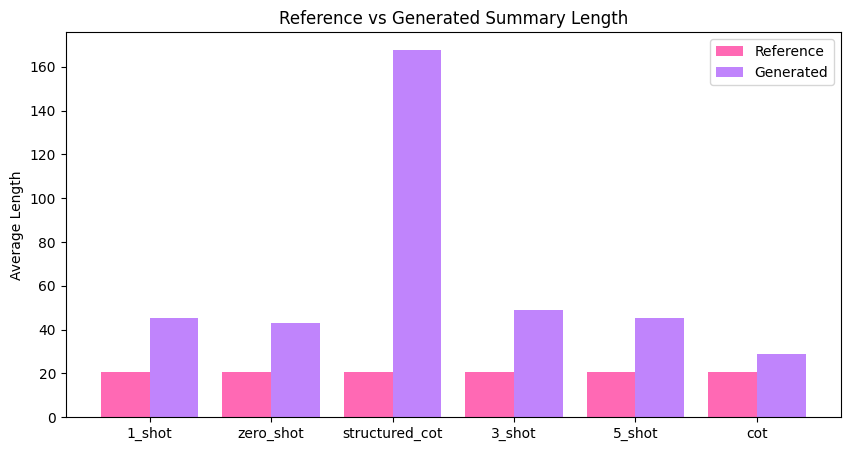

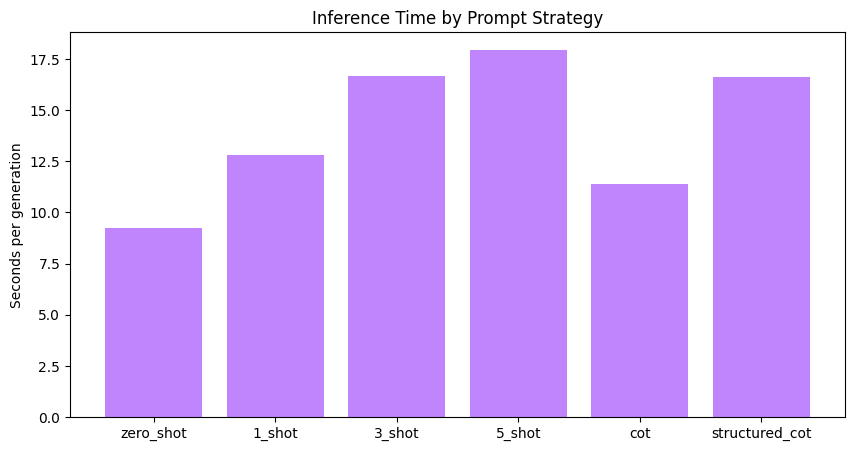

In [45]:
pink = "#ff69b4"
purple = "#c084fc"

# BLEU comparison
prompt_bleu = results_df[["method", "bleu_score"]].copy()
prompt_bleu.columns = ["Method", "BLEU"]

phi3_bleu = results[["prompting_strategy", "bleu_score"]].copy()
phi3_bleu["Method"] = "Phi-3 mini + " + phi3_bleu["prompting_strategy"]
phi3_bleu.columns = ["prompting_strategy", "BLEU", "Method"]
phi3_bleu = phi3_bleu[["Method", "BLEU"]]

comparison_df = pd.concat([prompt_bleu, phi3_bleu], ignore_index=True)
comparison_df = comparison_df.sort_values("BLEU", ascending=False)

display(comparison_df)

plt.figure(figsize=(12, 6))
colors = [purple if "Phi-3" in m else pink for m in comparison_df["Method"]]
plt.bar(comparison_df["Method"], comparison_df["BLEU"], color=colors)
plt.title("BLEU Score Comparison")
plt.ylabel("BLEU")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# BLEU vs length
plt.figure(figsize=(8, 6))
plt.scatter(results_df["generated_mean_length"], results_df["bleu_score"], color=pink, s=100)

for i in range(len(results_df)):
    plt.text(results_df["generated_mean_length"].iloc[i],
             results_df["bleu_score"].iloc[i],
             results_df["method"].iloc[i])

plt.xlabel("Generated Summary Length")
plt.ylabel("BLEU Score")
plt.title("BLEU vs Generated Summary Length")
plt.grid(alpha=0.3)
plt.show()

# length comparison
methods = results_df["method"]
ref_len = results_df["reference_mean_length"]
gen_len = results_df["generated_mean_length"]
x = np.arange(len(methods))

plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, ref_len, width=0.4, color=pink, label="Reference")
plt.bar(x + 0.2, gen_len, width=0.4, color=purple, label="Generated")
plt.xticks(x, methods)
plt.ylabel("Average Length")
plt.title("Reference vs Generated Summary Length")
plt.legend()
plt.show()

# inference time
methods = ["zero_shot", "1_shot", "3_shot", "5_shot", "cot", "structured_cot"]
time_per_iter = [9.25, 12.81, 16.68, 17.91, 11.41, 16.60]

plt.figure(figsize=(10, 5))
plt.bar(methods, time_per_iter, color=purple)
plt.ylabel("Seconds per generation")
plt.title("Inference Time by Prompt Strategy")
plt.show()